In [22]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
import e57
import ezdxf
import os
import sys
import pandas as pd

In [23]:
# Config pour l'enregistrement des graphes : nom = {fichier_e57}_{methode}.png
# Adapter e57_path pour qu'il corresponde au fichier E57 chargé.
import matplotlib.pyplot as _mpl

e57_path = r"C:\Users\mvm\open3d_vision\data\67.dxf"
_output_dir = r"C:\Users\mvm\open3d_vision\data"

def enregistrer_graphe(methode):
    """Enregistre la figure courante sous {nom_e57}_{methode}.png (à appeler avant plt.show())."""
    import os
    base = os.path.splitext(os.path.basename(e57_path))[0]
    os.makedirs(_output_dir, exist_ok=True)
    path = os.path.join(_output_dir, f"{base}_{methode}.png")
    _mpl.gcf().savefig(path, dpi=150, bbox_inches="tight")
    print(f"Graphe enregistré : {path}")

In [24]:
def e57_to_dxf(
    source,
    dxf_path: str,
    voxel_size: float = 0.01,
    max_points: int = 50_000,
    k_neighbors: int = 2,
    max_edge_length: float = 0.1,
    project_2d: bool = False,
    z_min: float = 2.9,
    z_max: float = 3.1,
) -> None:
    """
    Convertit un nuage de points en dessin DXF.
    - source : chemin (str) vers un fichier E57, ou o3d.geometry.PointCloud (ex. pcd_downsampled)
    - Si str : lecture E57, limite max_points, filtre z, puis voxel_down_sample
    - Si PointCloud : utilise directement les points (optionnel max_points et filtre z)
    - Interpolation de lignes entre voisins (k-NN, max_edge_length)
    """
    import open3d as o3d
    from scipy.spatial import cKDTree

    if isinstance(source, str):
        pc = e57.read_points(source)
        pts = np.asarray(pc.points, dtype=np.float64)
        if len(pts) > max_points:
            idx = np.random.choice(len(pts), max_points, replace=False)
            pts = pts[idx]
        pts = pts[(pts[:, 2] >= z_min) & (pts[:, 2] <= z_max)]
        pcd = o3d.geometry.PointCloud()
        pcd.points = o3d.utility.Vector3dVector(pts)
        pcd_down = pcd.voxel_down_sample(voxel_size)
        pts = np.asarray(pcd_down.points)
    else:
        pts = np.asarray(source.points, dtype=np.float64)
        if len(pts) > max_points:
            idx = np.random.choice(len(pts), max_points, replace=False)
            pts = pts[idx]
        # Pas de filtre Z pour un PointCloud : on garde tous les points (évite un DXF vide)
    


    if project_2d:
        pts_work = np.column_stack([pts[:, :2], np.zeros(len(pts))])
    else:
        pts_work = pts

    # Construction d'un arbre spatial pour la recherche efficace des voisins les plus proches
    tree = cKDTree(pts_work)
    seen = set()   # Ensemble pour garder trace des arêtes déjà ajoutées (évite les doublons)
    lines = []     # Liste qui stockera toutes les lignes (arêtes) à dessiner dans le DXF

    # Parcours de chaque point du nuage
    for idx_point in range(len(pts_work)):
        # Pour chaque point, on recherche ses k voisins les plus proches (k_neighbors+1, car le point lui-même est toujours le plus proche)
        distances, neighbor_indices = tree.query(pts_work[idx_point], k=k_neighbors + 1)
        for neighbor_rank, (distance, idx_neighbor) in enumerate(zip(distances, neighbor_indices)):
            # Ignore le premier voisin (soi-même) ou toute redondance
            if neighbor_rank == 0 or idx_neighbor == idx_point:
                continue
            # Ignore les voisins trop éloignés (au-delà du seuil max_edge_length)
            if distance > max_edge_length:
                continue
            # Définit l'arête de façon unique indépendamment de l'ordre des points (pour éviter les doublons)
            edge = tuple(sorted([idx_point, idx_neighbor]))
            if edge not in seen:
                seen.add(edge)  # Marque cette arête comme traitée
                # Ajoute la ligne (segment entre les deux points) à la liste des lignes
                lines.append((pts_work[idx_point].tolist(), pts_work[idx_neighbor].tolist()))

    doc = ezdxf.new("R2010")
    msp = doc.modelspace()
    for (p1, p2) in lines:
        msp.add_line(p1, p2, dxfattribs={"layer": "POINTS"})
    doc.saveas(dxf_path)
    print(f"Exporte: {len(pts)} points, {len(lines)} lignes -> {dxf_path}")



In [25]:
original_plt = e57.read_points(r"C:\Users\mvm\open3d_vision\data\67.e57")
new_dwg = e57_to_dxf(original_plt, r"C:\Users\mvm\open3d_vision\data\67.dxf",max_edge_length=0.05,z_min=0.0,z_max=0.4)

Exporte: 50000 points, 59205 lignes -> C:\Users\mvm\open3d_vision\data\67.dxf


In [26]:
plt = e57.read_points(r"C:\Users\mvm\open3d_vision\data\67.e57")

In [27]:
# Dimensions de la bounding box du nuage de points (plt)
pts = np.asarray(plt.points, dtype=np.float64)
x_min, x_max = float(pts[:, 0].min()), float(pts[:, 0].max())
y_min, y_max = float(pts[:, 1].min()), float(pts[:, 1].max())
z_min, z_max = float(pts[:, 2].min()), float(pts[:, 2].max())
dx, dy, dz = x_max - x_min, y_max - y_min, z_max - z_min
print("Bounding box du nuage plt")
print(f"  X : [{x_min:.3f}, {x_max:.3f}] m  →  largeur  = {dx:.3f} m")
print(f"  Y : [{y_min:.3f}, {y_max:.3f}] m  →  profondeur = {dy:.3f} m")
print(f"  Z : [{z_min:.3f}, {z_max:.3f}] m  →  hauteur = {dz:.3f} m")
print(f"  Nombre de points : {len(pts)}")

Bounding box du nuage plt
  X : [11.153, 15.657] m  →  largeur  = 4.504 m
  Y : [-4.179, 2.705] m  →  profondeur = 6.884 m
  Z : [-4.813, 3.564] m  →  hauteur = 8.377 m
  Nombre de points : 11532410


In [28]:
import pyransac
from pyransac import line2d
import numpy as np
    
# # pyransac Line2D attend des Point2D (attributs .x, .y), pas un tableau numpy
# points_2d = [line2d.Point2D(p[0], p[1]) for p in plt.points]

# # Paramètres RANSAC
# params = pyransac.RansacParams(samples=2,
#                               iterations=5,
#                               confidence=0.999,
#                               threshold=1)
# model = line2d.Line2D()
# inliers_pt2d = pyransac.find_inliers(points=points_2d, model=model, params=params)
# # Reconversion en numpy (N, 3) pour Open3D / visualisation
# inliers = np.array([[p.x, p.y, 0.0] for p in inliers_pt2d])


In [29]:
plte57 = plt

In [30]:
new_new_plt = o3d.geometry.PointCloud()
new_new_plt.points = o3d.utility.Vector3dVector(plt.points)
o3d.visualization.draw_geometries([new_new_plt], window_name='new_plt point cloud réduit')

In [31]:
new_plt = plt.points[(plt.points[:,2] >= 2.9) & (plt.points[:,2] <= 3.1)]
print(new_plt)
print(new_plt.shape)


[[13.55521107 -2.20844626  2.96326661]
 [13.47916126 -2.26413178  3.07958269]
 [13.05905247 -2.29175091  3.01561427]
 ...
 [13.5900259  -1.58954108  2.93233991]
 [13.82824802 -2.00940394  3.09134483]
 [12.94160366 -2.62545681  3.01400113]]
(8304, 3)


In [32]:
new_plt[:,2] = 0

In [33]:

new_new_plt = o3d.geometry.PointCloud()
new_new_plt.points = o3d.utility.Vector3dVector(new_plt)
o3d.visualization.draw_geometries([new_new_plt], window_name='new_plt point cloud réduit')

In [34]:
import open3d as o3d
import numpy as np

# Convert new_plt to Open3D PointCloud
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(new_plt)

# Réduction de la quantité de points en regroupant par voxelization (regroupement spatial/densité)
voxel_size = 0.08  # Ajuste la taille du voxel selon la densité désirée
pcd_downsampled = pcd.voxel_down_sample(voxel_size=voxel_size)

print(f"Nombre de points original : {np.asarray(pcd.points).shape[0]}")
print(f"Nombre de points après réduction : {np.asarray(pcd_downsampled.points).shape[0]}")

# Visualisation du nuage de points réduit
o3d.visualization.draw_geometries([pcd_downsampled], window_name='new_plt point cloud réduit')

Nombre de points original : 8304
Nombre de points après réduction : 60


Alpha-shape : 45 arêtes de contour (alpha=0.5)
Exporté -> C:\Users\mvm\open3d_vision\data\67_alpha_shape.dxf
Graphe enregistré : C:\Users\mvm\open3d_vision\data\67_contour_alpha_shape.png


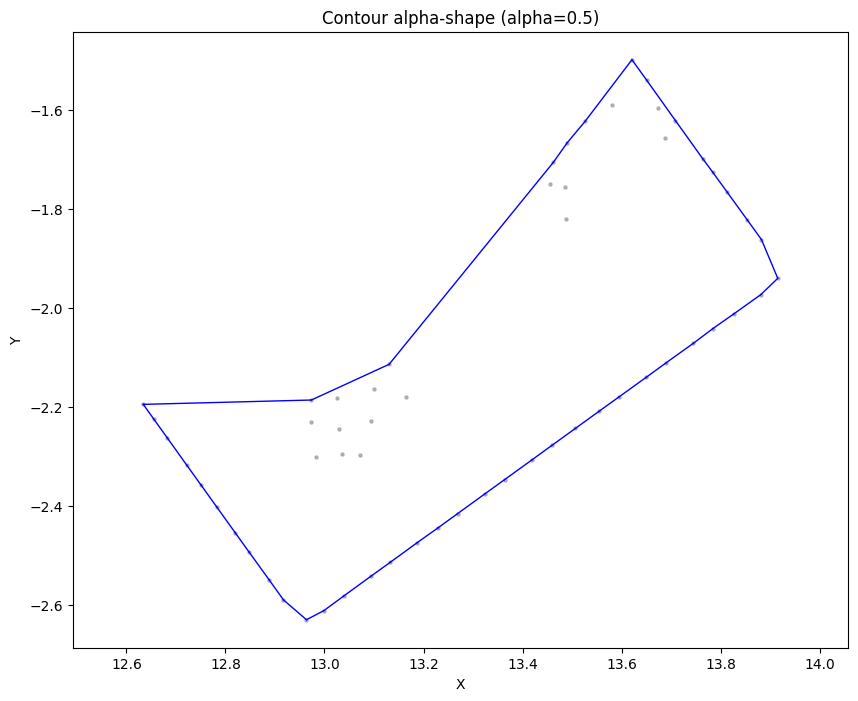

In [35]:
# Estimation de droites / contour par alpha-shape (2D, plan XY)
# Un triangle est gardé si le rayon de son cercle circonscrit <= alpha
from scipy.spatial import Delaunay

def alpha_shape_edges(pcd, alpha):
    """
    Extrait les arêtes du contour (alpha-shape) du nuage projeté en 2D (XY).
    pcd : o3d.geometry.PointCloud
    alpha : rayon max du cercle circonscrit pour garder une arête (plus petit = contour plus serré)
    Retourne : liste de ((x1,y1,z1), (x2,y2,z2))
    """
    pts = np.asarray(pcd.points)
    if len(pts) < 3:
        return []
    pts_2d = pts[:, :2]
    tri = Delaunay(pts_2d)
    z_mean = pts[:, 2].mean()

    def circumradius_2d(p0, p1, p2):
        a = np.linalg.norm(p1 - p0)
        b = np.linalg.norm(p2 - p0)
        c = np.linalg.norm(p2 - p1)
        if a * b * c < 1e-12:
            return np.inf
        area = 0.5 * abs((p1[0] - p0[0]) * (p2[1] - p0[1]) - (p2[0] - p0[0]) * (p1[1] - p0[1]))
        if area < 1e-12:
            return np.inf
        return (a * b * c) / (4 * area)

    edge_count = {}
    for s in tri.simplices:
        p0, p1, p2 = pts_2d[s[0]], pts_2d[s[1]], pts_2d[s[2]]
        r = circumradius_2d(p0, p1, p2)
        if r <= alpha:
            for i, j in [(0, 1), (1, 2), (2, 0)]:
                ei, ej = s[i], s[j]
                edge = tuple(sorted([ei, ej]))
                edge_count[edge] = edge_count.get(edge, 0) + 1

    # Arêtes frontière = présentes dans exactement un triangle
    lines = []
    for (i, j), count in edge_count.items():
        if count == 1:
            pi = (float(pts[i, 0]), float(pts[i, 1]), float(pts[i, 2]))
            pj = (float(pts[j, 0]), float(pts[j, 1]), float(pts[j, 2]))
            lines.append((pi, pj))
    return lines

# Calcul du contour alpha-shape (ajuster alpha si besoin : plus grand = contour plus lisse)
alpha = 0.5
edges_alpha = alpha_shape_edges(pcd_downsampled, alpha)
print(f"Alpha-shape : {len(edges_alpha)} arêtes de contour (alpha={alpha})")

# Export DXF des arêtes alpha-shape
if edges_alpha:
    doc = ezdxf.new("R2010")
    msp = doc.modelspace()
    for (p1, p2) in edges_alpha:
        msp.add_line(p1, p2, dxfattribs={"layer": "ALPHA_SHAPE"})
    out_path = r"C:\Users\mvm\open3d_vision\data\67_alpha_shape.dxf"
    doc.saveas(out_path)
    print(f"Exporté -> {out_path}")

# Visualisation rapide du contour (optionnel)
import matplotlib.pyplot as mpl
pts = np.asarray(pcd_downsampled.points)
mpl.figure(figsize=(10, 8))
mpl.scatter(pts[:, 0], pts[:, 1], s=5, c="gray", alpha=0.5)
for (p1, p2) in edges_alpha:
    mpl.plot([p1[0], p2[0]], [p1[1], p2[1]], "b-", lw=1)
mpl.axis("equal")
mpl.title(f"Contour alpha-shape (alpha={alpha})")
mpl.xlabel("X")
mpl.ylabel("Y")
enregistrer_graphe("contour_alpha_shape")
mpl.show()

In [36]:
e57_to_dxf(pcd_downsampled , r"C:\Users\mvm\open3d_vision\data\67_downsampled.dxf")

Exporte: 60 points, 66 lignes -> C:\Users\mvm\open3d_vision\data\67_downsampled.dxf


Graphe enregistré : C:\Users\mvm\open3d_vision\data\67_slice_batiment.png


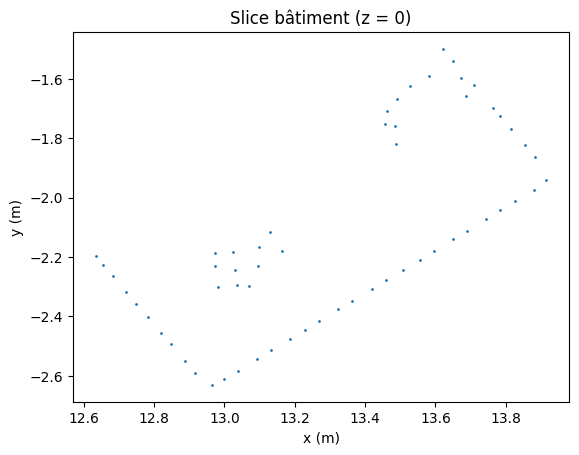

Graphe enregistré : C:\Users\mvm\open3d_vision\data\67_hough_espace.png


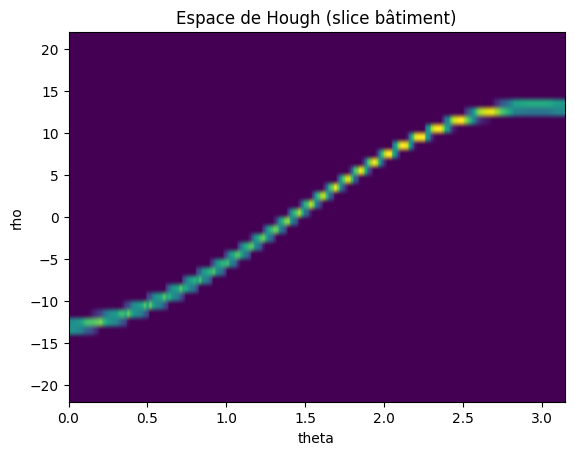

Droites détectées (rho, theta) :
(np.float64(-11.767441860465116), np.float64(2.4746623695874903))
(np.float64(-11.767441860465116), np.float64(2.4922131665349196))
(np.float64(-10.744186046511627), np.float64(2.3342559940080583))
(np.float64(-10.744186046511627), np.float64(2.3518067909554876))
Graphe enregistré : C:\Users\mvm\open3d_vision\data\67_hough_droites.png


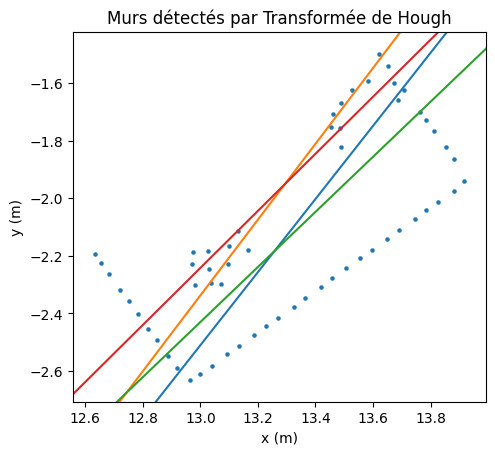

In [37]:
# Hough INUTILE
# =========================================
# Cell 1 — Simulation d'un slice bâtiment (z = 0)
# =========================================

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)

# Rectangle bâtiment 20m x 10m
walls = []

# # Mur bas
# x1 = np.linspace(0, 20, 200)
# y1 = np.zeros_like(x1)

# # Mur haut
# x2 = np.linspace(0, 20, 200)
# y2 = np.full_like(x2, 10)

# # Mur gauche
# y3 = np.linspace(0, 10, 150)
# x3 = np.zeros_like(y3)

# # Mur droit
# y4 = np.linspace(0, 10, 150)
# x4 = np.full_like(y4, 20)

# # Bruit intérieur
# x_noise = np.random.uniform(0, 20, 400)
# y_noise = np.random.uniform(0, 10, 400)

# x_all = np.concatenate([x1, x2, x3, x4, x_noise])
# y_all = np.concatenate([y1, y2, y3, y4, y_noise])

plt.figure()

pts = np.asarray(pcd_downsampled.points)
plt.scatter(pts[:,0], pts[:,1], s=1, label='Points intérieurs')
plt.title("Slice bâtiment (z = 0)")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
enregistrer_graphe("slice_batiment")
plt.show()


# =========================================
# Cell 2 — Transformée de Hough
# =========================================

theta_res = 180
thetas = np.linspace(0, np.pi, theta_res)

diag_len = int(np.sqrt(20**2 + 10**2))
rhos = np.linspace(-diag_len, diag_len, 2 * diag_len)

accumulator = np.zeros((len(rhos), len(thetas)))

for x, y in zip(pts[:,0], pts[:,1]):
    for t_idx, theta in enumerate(thetas):
        rho = x * np.cos(theta) + y * np.sin(theta)
        rho_idx = np.argmin(np.abs(rhos - rho))
        accumulator[rho_idx, t_idx] += 1

plt.figure()
plt.imshow(accumulator, extent=[0, np.pi, -diag_len, diag_len], aspect='auto')
plt.title("Espace de Hough (slice bâtiment)")
plt.xlabel("theta")
plt.ylabel("rho")
enregistrer_graphe("hough_espace")
plt.show()


# =========================================
# Cell 3 — Extraction des 4 pics principaux
# =========================================

peaks = []

temp_acc = accumulator.copy()

for _ in range(4):
    idx = np.unravel_index(np.argmax(temp_acc), temp_acc.shape)
    peaks.append((rhos[idx[0]], thetas[idx[1]]))
    temp_acc[idx] = 0

print("Droites détectées (rho, theta) :")
for p in peaks:
    print(p)


# =========================================
# Cell 4 — Reconstruction des droites détectées
# =========================================

plt.figure()
plt.scatter(pts[:,0], pts[:,1], s=5)

x_vals = np.linspace(-5, 25, 400)
hough_lines_xy = []  # conserve (xv, yv) par pic pour le rendu final

for rho_max, theta_max in peaks:
    if abs(np.sin(theta_max)) > 1e-9:
        y_vals = (rho_max - x_vals * np.cos(theta_max)) / np.sin(theta_max)
        hough_lines_xy.append((x_vals.copy(), y_vals.copy()))
        plt.plot(x_vals, y_vals)
    else:
        x_const = rho_max / np.cos(theta_max)
        y_vals = np.linspace(-5, 15, 400)
        xv = np.full_like(y_vals, x_const)
        hough_lines_xy.append((xv.copy(), y_vals.copy()))
        plt.plot(xv, y_vals)

# Zoom sur le nuage de points (cadre = bbox des pts + marge)
xm, xM = float(pts[:, 0].min()), float(pts[:, 0].max())
ym, yM = float(pts[:, 1].min()), float(pts[:, 1].max())
span = max(xM - xm, yM - ym, 1e-9)
pad = 0.06 * span
plt.xlim(xm - pad, xM + pad)
plt.ylim(ym - pad, yM + pad)
plt.gca().set_aspect("equal", adjustable="box")

plt.title("Murs détectés par Transformée de Hough")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
enregistrer_graphe("hough_droites")
plt.show()


Graphe enregistré : C:\Users\mvm\open3d_vision\data\67_ransac_droites.png


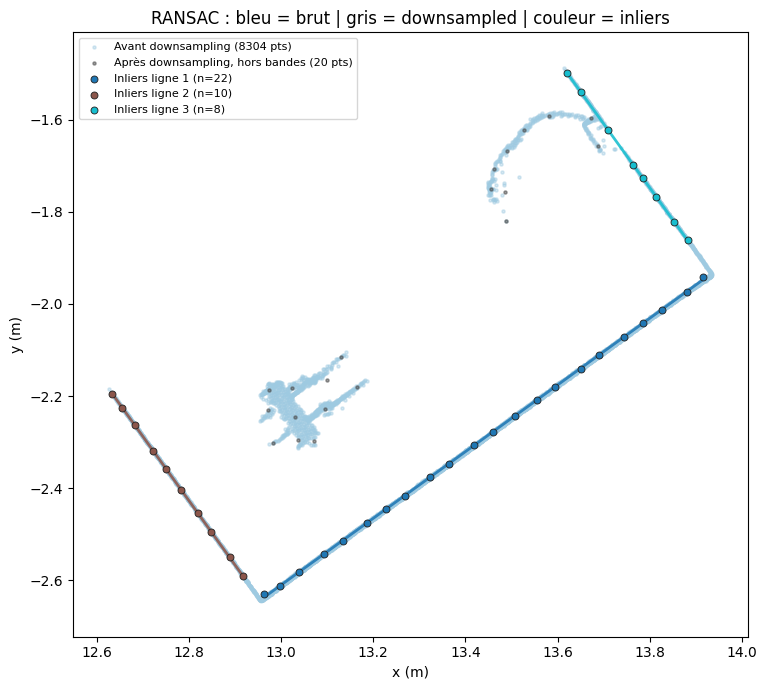

RANSAC : 3 droite(s) détectée(s). Ajuster dist_thresh (ex. 0.08–0.2 m) si besoin.


In [38]:
# =========================================
# Alternative : droites par RANSAC itératif
# =========================================
# Principe : tirer au hasard des paires de points, compter les points proches
# d'une droite (inliers), garder la meilleure, affiner par SVD sur les inliers,
# retirer ces points et recommencer. Cible les alignements localement linéaires.

def ransac_line_from_points(xy, dist_thresh, n_draws, rng):
    """
    Une passe RANSAC : retourne (p0, d_unit, inlier_mask) ou None.
    xy : (N, 2), d_unit direction unitaire de la droite.
    """
    n = len(xy)
    if n < 2:
        return None
    best_count, best_mask = 0, None
    best_p0, best_d = None, None
    for _ in range(n_draws):
        i, j = rng.integers(0, n, size=2)
        if i == j:
            continue
        p0, p1 = xy[i], xy[j]
        d = p1 - p0
        L = np.linalg.norm(d)
        if L < 1e-12:
            continue
        d = d / L
        v = xy - p0
        dist = np.abs(v[:, 0] * d[1] - v[:, 1] * d[0])
        mask = dist < dist_thresh
        c = int(mask.sum())
        if c > best_count:
            best_count, best_mask = c, mask
            best_p0, best_d = p0.copy(), d.copy()
    if best_mask is None or best_count < 3:
        return None
    # Affinage : axe principal des inliers (TLS / SVD)
    inc = xy[best_mask]
    c = inc.mean(axis=0)
    _, _, vt = np.linalg.svd(inc - c, full_matrices=False)
    d_ref = vt[0]
    d_ref = d_ref / (np.linalg.norm(d_ref) + 1e-12)
    t = (inc - c) @ d_ref
    p_a = c + d_ref * t.min()
    p_b = c + d_ref * t.max()
    # ré-évalue inliers sur la droite affinée
    v2 = xy - c
    dist2 = np.abs(v2[:, 0] * d_ref[1] - v2[:, 1] * d_ref[0])
    mask2 = dist2 < dist_thresh
    return p_a, p_b, d_ref, mask2


def iterative_ransac_lines(xy, dist_thresh=0.12, n_draws=800, max_lines=6, min_inliers=8, seed=42):
    """
    Extrait jusqu'à max_lines droites ; retire les inliers à chaque étape.
    Retourne une liste de (p_a, p_b, indices_inliers) avec indices dans le nuage d'origine.
    """
    rng = np.random.default_rng(seed)
    work = np.asarray(xy, dtype=np.float64).copy()
    idx_work = np.arange(len(work), dtype=np.int64)
    lines_seg = []
    while len(work) >= min_inliers and len(lines_seg) < max_lines:
        out = ransac_line_from_points(work, dist_thresh, n_draws, rng)
        if out is None:
            break
        p_a, p_b, d_ref, mask = out
        if mask.sum() < min_inliers:
            break
        inlier_idx = idx_work[mask]
        lines_seg.append((p_a.copy(), p_b.copy(), inlier_idx.copy()))
        idx_work = idx_work[~mask]
        work = work[~mask]
    return lines_seg


xy = np.asarray(pts[:, :2], dtype=np.float64)
xy_avant_ds = np.asarray(new_plt[:, :2], dtype=np.float64)  # même slice Z, avant voxel_down_sample
ransac_segs = iterative_ransac_lines(
    xy, dist_thresh=0.01, n_draws=1000, max_lines=6, min_inliers=8, seed=42
)

plt.figure(figsize=(8, 7))
# Même taille de point pour comparer : bleu = brut, gris = downsampled (hors RANSAC)
_s_nuage = 5
plt.scatter(
    xy_avant_ds[:, 0], xy_avant_ds[:, 1], s=_s_nuage, c="#9ecae1", alpha=0.42,
    label=f"Avant downsampling ({len(xy_avant_ds)} pts)", zorder=0, rasterized=True,
)
on_line = np.zeros(len(xy), dtype=bool)
for _, _, ig in ransac_segs:
    on_line[ig] = True
plt.scatter(
    xy[~on_line, 0], xy[~on_line, 1], s=_s_nuage, c="#4d4d4d", alpha=0.55,
    label=f"Après downsampling, hors bandes ({int((~on_line).sum())} pts)", zorder=1,
)
cols = plt.cm.tab10(np.linspace(0, 1, max(len(ransac_segs), 1)))
for k, (pa, pb, ig) in enumerate(ransac_segs):
    plt.plot([pa[0], pb[0]], [pa[1], pb[1]], "-", color=cols[k], lw=2.0, zorder=2, alpha=0.88)
    # Inliers : légèrement plus grands + bordure (même ordre de taille que les nuages)
    plt.scatter(
        xy[ig, 0], xy[ig, 1], s=_s_nuage * 5, c=[cols[k]], edgecolors="0.15", linewidths=0.65,
        zorder=4, marker="o", label=f"Inliers ligne {k+1} (n={len(ig)})",
    )
xm = min(float(xy[:, 0].min()), float(xy_avant_ds[:, 0].min()))
xM = max(float(xy[:, 0].max()), float(xy_avant_ds[:, 0].max()))
ym = min(float(xy[:, 1].min()), float(xy_avant_ds[:, 1].min()))
yM = max(float(xy[:, 1].max()), float(xy_avant_ds[:, 1].max()))
span = max(xM - xm, yM - ym, 1e-9)
pad = 0.06 * span
plt.xlim(xm - pad, xM + pad)
plt.ylim(ym - pad, yM + pad)
plt.gca().set_aspect("equal", adjustable="box")
plt.title("RANSAC : bleu = brut | gris = downsampled | couleur = inliers")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.legend(loc="best", fontsize=8)
plt.tight_layout()
enregistrer_graphe("ransac_droites")
plt.show()
print(f"RANSAC : {len(ransac_segs)} droite(s) détectée(s). Ajuster dist_thresh (ex. 0.08–0.2 m) si besoin.")

Graphe enregistré : C:\Users\mvm\open3d_vision\data\67_tranche_sans_downsampling.png


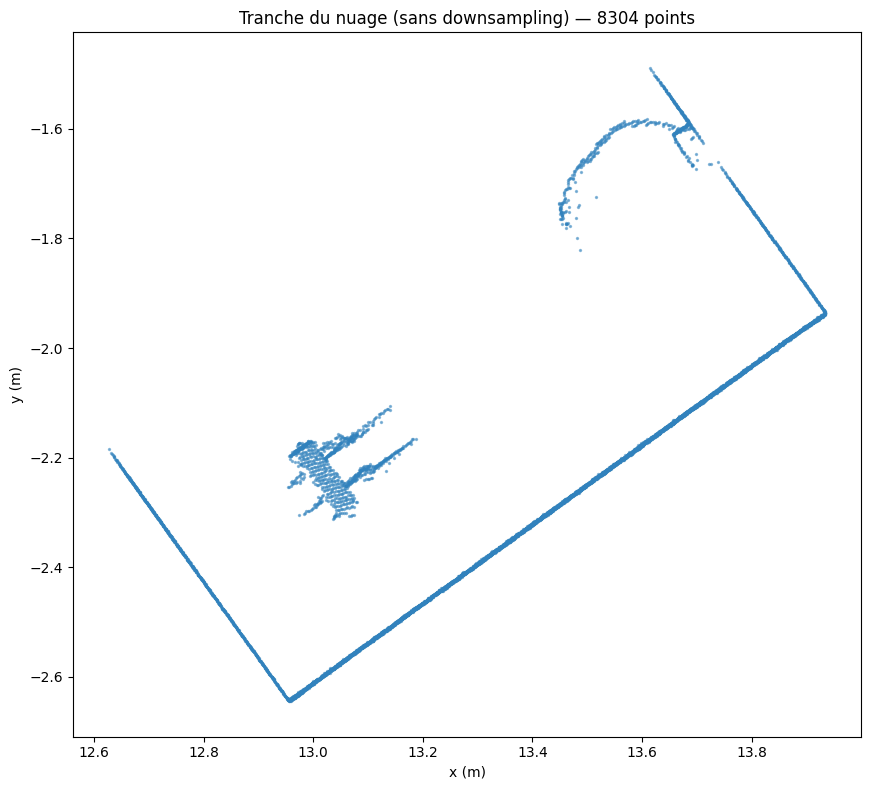

In [39]:
# Visualisation 2D de la tranche du nuage SANS downsampling (densité complète)
import matplotlib.pyplot as plt

xy_slice = np.asarray(new_plt[:, :2], dtype=np.float64)
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(xy_slice[:, 0], xy_slice[:, 1], s=2, c="#3182bd", alpha=0.5, rasterized=True)
ax.set_aspect("equal", adjustable="box")
xm, xM = xy_slice[:, 0].min(), xy_slice[:, 0].max()
ym, yM = xy_slice[:, 1].min(), xy_slice[:, 1].max()
span = max(xM - xm, yM - ym, 1e-9)
pad = 0.05 * span
ax.set_xlim(xm - pad, xM + pad)
ax.set_ylim(ym - pad, yM + pad)
ax.set_title(f"Tranche du nuage (sans downsampling) — {len(xy_slice)} points")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
plt.tight_layout()
enregistrer_graphe("tranche_sans_downsampling")
plt.show()

In [40]:
def _dist_pts_to_line(xy_pts, p0, d_unit):
    """Distances orthogonales des points à la droite (p0, direction unitaire)."""
    v = xy_pts - p0
    return np.abs(v[:, 0] * d_unit[1] - v[:, 1] * d_unit[0])


def mae_ransac_vs_tranche_dense(ransac_segs, xy_dense, bande_m=0.05): 
    """
    mae_tous : MAE sur tous les points (intérieur inclus → souvent élevée).
    mae_proches : MAE des points à < bande_m d'au moins une droite (ajustement aux murs).
    """
    if not ransac_segs:
        return None
    xy_dense = np.asarray(xy_dense, dtype=np.float64)
    lignes = []
    for pa, pb, _ in ransac_segs:
        d = np.asarray(pb, float) - np.asarray(pa, float)
        L = np.linalg.norm(d)
        if L < 1e-12:
            continue
        d = d / L
        c = 0.5 * (np.asarray(pa, float) + np.asarray(pb, float))
        lignes.append((c, d))
    if not lignes:
        return None
    D = np.column_stack([_dist_pts_to_line(xy_dense, p0, d) for p0, d in lignes])
    d_min = D.min(axis=1)
    proche = d_min < bande_m
    return {
        "mae_tous_points_m": float(np.mean(d_min)),
        "mae_mediane_tous_m": float(np.median(d_min)),
        "mae_sous_bande_m": float(np.mean(d_min[proche])) if np.any(proche) else float("nan"),
        "n_sous_bande": int(proche.sum()),
        "n_total": len(xy_dense),
        "bande_m": bande_m,
    }

In [41]:
# Enregistrer tous les graphes produits par le notebook
# Nom des fichiers : {nom_fichier_e57}_{methode}.png
# À exécuter après avoir exécuté les cellules de visualisation.

import os
import matplotlib.pyplot as mpl

# Chemin du fichier E57 chargé (même que pour plt = e57.read_points(...))
e57_path = r"C:\Users\mvm\OneDrive - Group Seco\Desktop\25-GO1886 ALL.e57"
base = os.path.splitext(os.path.basename(e57_path))[0]
output_dir = r"C:\Users\mvm\open3d_vision\data"
os.makedirs(output_dir, exist_ok=True)

# Méthodes dans l'ordre des figures créées (adapter si l'ordre d'exécution change)
methodes = [
    "contour_alpha_shape",
    "hough_droites",
    "ransac_droites",
    "ransac_cercles",
    "tranche_sans_downsampling",
]

for i, fig_num in enumerate(mpl.get_fignums()):
    method = methodes[i] if i < len(methodes) else f"figure_{i}"
    filename = f"{base}_{method}.png"
    path = os.path.join(output_dir, filename)
    mpl.figure(fig_num).savefig(path, dpi=150, bbox_inches="tight")
    print(f"Enregistré : {path}")
if not mpl.get_fignums():
    print("Aucune figure ouverte. Exécuter d'abord les cellules de visualisation.")

Aucune figure ouverte. Exécuter d'abord les cellules de visualisation.


In [42]:
# Score MAE : droites RANSAC vs tranche dense (avant downsampling)
# Pour chaque point : distance orthogonale minimale aux droites RANSAC ; MAE = moyenne.
scores = mae_ransac_vs_tranche_dense(ransac_segs, xy_avant_ds, bande_m=0.01)
if scores:
    print("--- MAE RANSAC vs tranche (avant downsampling) ---")
    print(f"  MAE n°1 (tous les points)      : {scores['mae_tous_points_m']:.4f} m")
    print(f"  Médiane des distances min. : {scores['mae_mediane_tous_m']:.4f} m")
    print(
        f"  MAE n°2 (pts à < {scores['bande_m']} m d'une droite, n={scores['n_sous_bande']}/{scores['n_total']}): "
        f"{scores['mae_sous_bande_m']:.4f} m"
    )
    print("  → La 2e MAE reflète mieux l'ajustement aux murs ; la 1ère pénalise l'intérieur.")
else:
    print("Aucune droite RANSAC : exécuter d'abord la cellule RANSAC.")

--- MAE RANSAC vs tranche (avant downsampling) ---
  MAE n°1 (tous les points)      : 0.0344 m
  Médiane des distances min. : 0.0008 m
  MAE n°2 (pts à < 0.01 m d'une droite, n=7139/8304): 0.0008 m
  → La 2e MAE reflète mieux l'ajustement aux murs ; la 1ère pénalise l'intérieur.


l'outil doit laisser plusieurs possibilités, méthode alpha shape ou méthode RANSAC